In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("synthetic_customer_churn_100k.csv")

In [14]:
data = data.drop(columns=["CustomerID"])

In [4]:
data["Contract"].value_counts()

data["Contract"]=data["Contract"].map({
    "Month-to-month":0,
    "One year":1,
    "Two year":2
})

In [5]:

data["Gender"] = data["Gender"].map({
    "Male":0,
    "Female":1
})

In [6]:
data["PaymentMethod"].value_counts()

map = {
    "Electronic check":0,
    "Mailed check":1,
    "Credit card":2,
    "Bank transfer":3,
}

data["PaymentMethod"] = data["PaymentMethod"].map(map)

In [7]:
data["Churn"] = data["Churn"].map({
    "Yes":0,
    "No":1
})



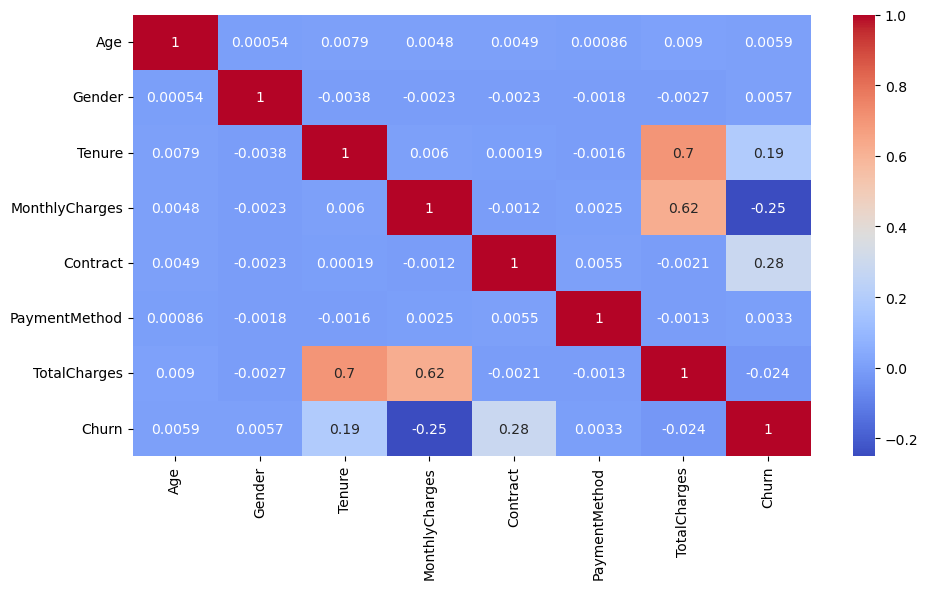

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(
    data.corr(),
    cmap='coolwarm',
    annot=True
)
plt.tight_layout()

In [16]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("synthetic_customer_churn_100k.csv")

# Drop unnecessary columns
df.drop("CustomerID", axis=1, inplace=True)

# Encode categorical columns
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])


In [17]:
X = df.drop("Churn", axis=1)
Y = df["Churn"]

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# Train model
rf_model.fit(X_train, Y_train)

# Predictions
Y_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(Y_test, Y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

Accuracy: 0.73555

Confusion Matrix:
[[11317  1977]
 [ 3312  3394]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81     13294
           1       0.63      0.51      0.56      6706

    accuracy                           0.74     20000
   macro avg       0.70      0.68      0.69     20000
weighted avg       0.73      0.74      0.73     20000



In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100,200,300,400,500],
    "min_samples_split":[50,100,200,300,400],
    "max_depth":[2,3,4,5,6]
}
best = RandomForestClassifier(
    random_state=42
)
gridcv = GridSearchCV(
    estimator=best,
    param_grid=param_grid,
    n_jobs=-1
)

gridcv.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_split': [50, 100, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [27]:
Y_pred = gridcv.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(Y_test, Y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

Accuracy: 0.7603

Confusion Matrix:
[[11467  1827]
 [ 2967  3739]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.83     13294
           1       0.67      0.56      0.61      6706

    accuracy                           0.76     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.75      0.76      0.75     20000



In [29]:
import pickle as pkl

with open('my_model.pkl', 'wb') as file:
    pkl.dump(gridcv, file)